In [3]:
import numpy as np
import matplotlib.pyplot as plt
# https://www.youtube.com/watch?v=G4zO53sVGV8

# Generacion de 2 señales sinusoidales

In [4]:
# Generar dos señales sinusoidales con diferente frecuencia
t = np.linspace(0, 1, 1000)
f1 = 5  # frecuencia de la primera señal en Hz
f2 = 10 # frecuencia de la segunda señal en Hz

s1 = np.sin(2 * np.pi * f1 * t)
s2 = np.sin(2 * np.pi * f2 * t)

# Grafica señales

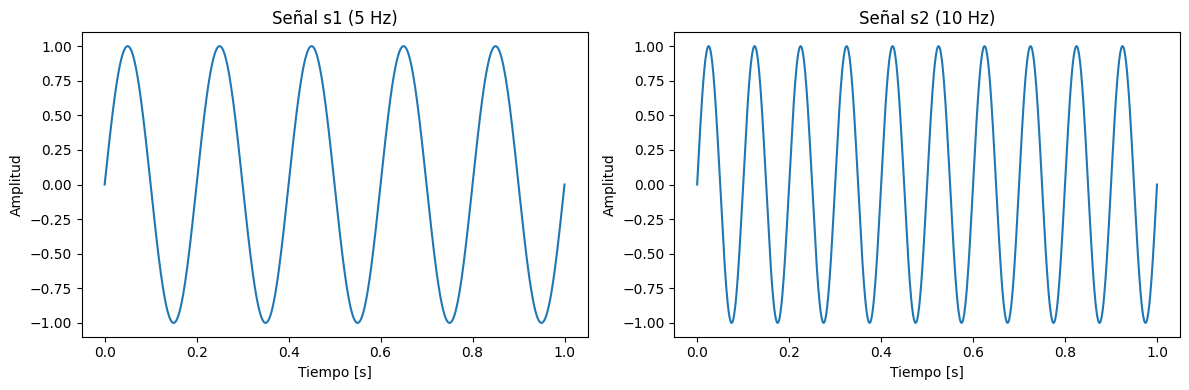

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(t, s1)
axs[0].set_title('Señal s1 (5 Hz)')
axs[0].set_xlabel('Tiempo [s]')
axs[0].set_ylabel('Amplitud')

axs[1].plot(t, s2)
axs[1].set_title('Señal s2 (10 Hz)')
axs[1].set_xlabel('Tiempo [s]')
axs[1].set_ylabel('Amplitud')

plt.tight_layout()
plt.show()

# Suma las dos señales

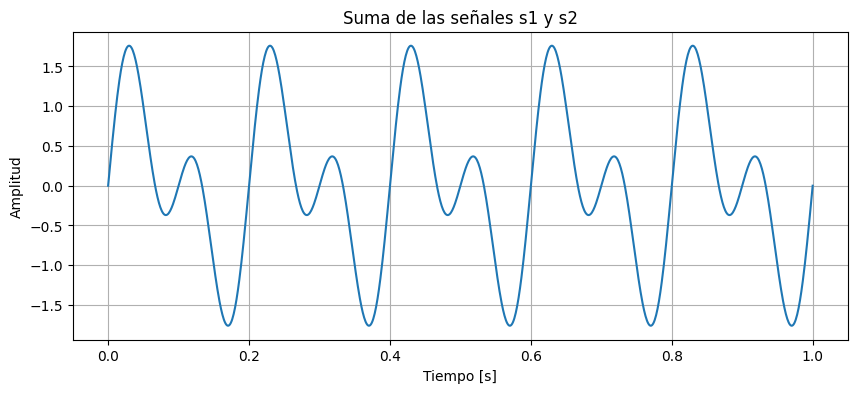

In [6]:
suma = s1 + s2

plt.figure(figsize=(10, 4))
plt.plot(t, suma)
plt.title('Suma de las señales s1 y s2')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()

# Pasamos al dominio frecuencia y mostramos el espectro de la señal

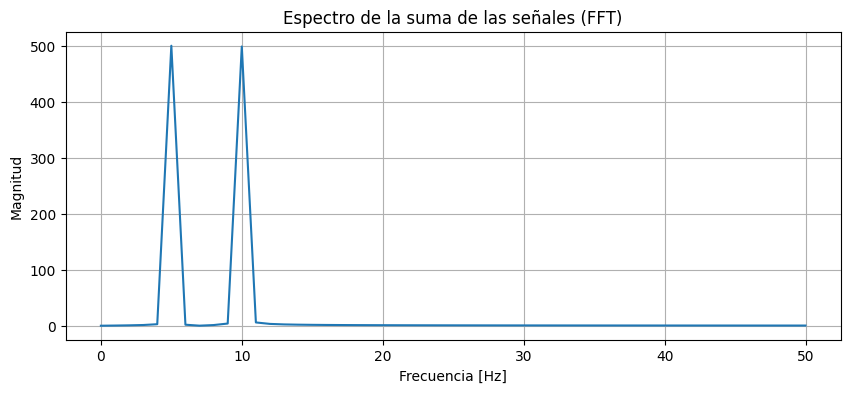

In [7]:
# Calcular la FFT de la señal suma
fft_suma = np.fft.fft(suma)
frecuencias = np.fft.fftfreq(len(t), d=t[1] - t[0])

# Solo tomamos la mitad positiva del espectro y delimitamos a 50 Hz
idx = frecuencias >= 0
idx_50hz = frecuencias <= 50

plt.figure(figsize=(10, 4))
plt.plot(frecuencias[idx & idx_50hz], np.abs(fft_suma[idx & idx_50hz]))
plt.title('Espectro de la suma de las señales (FFT)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud')
plt.grid(True)
plt.show()


# Filtra la señal de 10hz

In [ ]:
# Filtrar la señal de 10 Hz usando FFT (herramientas de numpy)
fft_suma = np.fft.fft(suma)
frecuencias = np.fft.fftfreq(len(t), d=t[1] - t[0])

# Creamos una copia para filtrar solo la componente de 10 Hz
fft_filtrada = fft_suma.copy()

# Eliminamos la componente de 10 Hz (y su simétrica negativa)
fft_filtrada[np.abs(frecuencias - 10) < 0.1] = 0
fft_filtrada[np.abs(frecuencias + 10) < 0.1] = 0

# Señal reconstruida sin la componente de 10 Hz
s_filtrada = np.fft.ifft(fft_filtrada).real

plt.figure(figsize=(10, 4))
plt.plot(t, s_filtrada)
plt.title('Señal suma filtrada (sin 10 Hz)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()

# Aplicando el mismo proceso a imágenes

Ahora vamos a aplicar el mismo concepto de filtrado frecuencial que usamos con las señales 1D, pero para imágenes (señales 2D).

## Conceptos clave:
- **FFT 1D**: Para señales temporales (como las que acabamos de ver)
- **FFT 2D**: Para imágenes, donde cada píxel es una "muestra" en el dominio espacial
- **Frecuencias espaciales**: Representan qué tan rápido cambian los valores de los píxeles en el espacio

In [ ]:
# Importar librerías adicionales para manejo de imágenes
import cv2
from scipy import ndimage # type: ignore
from PIL import Image

# Crear una imagen sintética (equivalente a nuestras señales sinusoidales)
# Creamos un patrón de frecuencias conocidas
rows, cols = 256, 256
x, y = np.meshgrid(np.arange(cols), np.arange(rows))

# Crear dos componentes de frecuencia (como nuestras señales de 5Hz y 10Hz)
freq_x1, freq_y1 = 0.05, 0.05  # Frecuencia baja (equivalente a 5Hz)
freq_x2, freq_y2 = 0.15, 0.15  # Frecuencia alta (equivalente a 10Hz)

# Generar los patrones sinusoidales 2D
pattern1 = np.sin(2 * np.pi * freq_x1 * x) + np.sin(2 * np.pi * freq_y1 * y)
pattern2 = np.sin(2 * np.pi * freq_x2 * x) + np.sin(2 * np.pi * freq_y2 * y)

# Sumar los patrones (equivalente a suma = s1 + s2)
imagen_compuesta = pattern1 + pattern2

print(f"Dimensiones de la imagen: {imagen_compuesta.shape}")
print(f"Rango de valores: [{imagen_compuesta.min():.2f}, {imagen_compuesta.max():.2f}]")

In [ ]:
# Visualizar las imágenes (equivalente a graficar s1, s2 y suma)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(pattern1, cmap='gray')
axs[0].set_title('Patrón 1 (Frecuencia baja)')
axs[0].axis('off')

axs[1].imshow(pattern2, cmap='gray')
axs[1].set_title('Patrón 2 (Frecuencia alta)')
axs[1].axis('off')

axs[2].imshow(imagen_compuesta, cmap='gray')
axs[2].set_title('Imagen compuesta (suma)')
axs[2].axis('off')

plt.tight_layout()
plt.show()

# FFT 2D - Transformada al dominio frecuencial

Ahora aplicamos FFT 2D (equivalente a nuestro análisis espectral de las señales)

In [ ]:
# Aplicar FFT 2D (equivalente a fft_suma = np.fft.fft(suma))
fft_imagen = np.fft.fft2(imagen_compuesta)
fft_imagen_shifted = np.fft.fftshift(fft_imagen)  # Centrar las frecuencias

# Calcular el espectro de magnitud
espectro_magnitud = np.log(np.abs(fft_imagen_shifted) + 1)  # +1 para evitar log(0)

# Crear las frecuencias espaciales (equivalente a frecuencias = np.fft.fftfreq(...))
freq_y = np.fft.fftfreq(rows, d=1.0)
freq_x = np.fft.fftfreq(cols, d=1.0)
freq_y_shifted = np.fft.fftshift(freq_y)
freq_x_shifted = np.fft.fftshift(freq_x)

print(f"Rango de frecuencias X: [{freq_x_shifted.min():.3f}, {freq_x_shifted.max():.3f}]")
print(f"Rango de frecuencias Y: [{freq_y_shifted.min():.3f}, {freq_y_shifted.max():.3f}]")

In [ ]:
# Visualizar el espectro de frecuencias (equivalente a graficar el espectro FFT)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(imagen_compuesta, cmap='gray')
axs[0].set_title('Imagen original')
axs[0].axis('off')

# Mostrar el espectro de magnitud
im = axs[1].imshow(espectro_magnitud, cmap='hot', extent=[freq_x_shifted.min(), freq_x_shifted.max(),
                                                          freq_y_shifted.min(), freq_y_shifted.max()])
axs[1].set_title('Espectro de magnitud (FFT 2D)')
axs[1].set_xlabel('Frecuencia espacial X')
axs[1].set_ylabel('Frecuencia espacial Y')

plt.tight_layout()
plt.show()

print("✓ Los puntos brillantes en el espectro representan las frecuencias dominantes")
print("✓ El centro corresponde a la componente DC (frecuencia 0)")
print("✓ Los picos simétricos muestran nuestras frecuencias de 0.05 y 0.15")

# Filtrado frecuencial en imágenes

Ahora aplicamos el mismo principio de filtrado que usaste con las señales 1D, pero en 2D

In [ ]:
# Crear filtros (equivalente a eliminar la componente de 10Hz)
# Vamos a crear diferentes tipos de filtros

# 1. Filtro paso bajo - elimina frecuencias altas (equivalente a eliminar la señal de 10Hz)
def crear_filtro_paso_bajo(shape, radio_corte):
    """Crea un filtro paso bajo circular"""
    rows, cols = shape
    center_row, center_col = rows // 2, cols // 2
    
    # Crear coordenadas
    y, x = np.ogrid[:rows, :cols]
    
    # Calcular distancia desde el centro
    distancia = np.sqrt((x - center_col)**2 + (y - center_row)**2)
    
    # Crear máscara (1 para pasar, 0 para bloquear)
    filtro = np.zeros((rows, cols))
    filtro[distancia <= radio_corte] = 1
    
    return filtro

# 2. Filtro paso alto - elimina frecuencias bajas (equivalente a eliminar la señal de 5Hz)
def crear_filtro_paso_alto(shape, radio_corte):
    """Crea un filtro paso alto circular"""
    filtro_paso_bajo = crear_filtro_paso_bajo(shape, radio_corte)
    return 1 - filtro_paso_bajo  # Invertir el filtro

# Crear los filtros
radio_bajo = 30    # Radio para filtro paso bajo
radio_alto = 20    # Radio para filtro paso alto

filtro_paso_bajo = crear_filtro_paso_bajo((rows, cols), radio_bajo)
filtro_paso_alto = crear_filtro_paso_alto((rows, cols), radio_alto)

print(f"Filtro paso bajo: elimina frecuencias > {radio_bajo} píxeles del centro")
print(f"Filtro paso alto: elimina frecuencias < {radio_alto} píxeles del centro")

In [ ]:
# Aplicar los filtros (equivalente a fft_filtrada[...] = 0)
# Aplicar filtro paso bajo
fft_filtrada_bajo = fft_imagen_shifted * filtro_paso_bajo
imagen_filtrada_bajo = np.fft.ifft2(np.fft.ifftshift(fft_filtrada_bajo)).real

# Aplicar filtro paso alto  
fft_filtrada_alto = fft_imagen_shifted * filtro_paso_alto
imagen_filtrada_alto = np.fft.ifft2(np.fft.ifftshift(fft_filtrada_alto)).real

print("✓ Filtros aplicados exitosamente")
print(f"Imagen original: rango [{imagen_compuesta.min():.2f}, {imagen_compuesta.max():.2f}]")
print(f"Filtro paso bajo: rango [{imagen_filtrada_bajo.min():.2f}, {imagen_filtrada_bajo.max():.2f}]")
print(f"Filtro paso alto: rango [{imagen_filtrada_alto.min():.2f}, {imagen_filtrada_alto.max():.2f}]")

In [ ]:
# Visualizar los resultados del filtrado
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# Primera fila: imágenes
axs[0, 0].imshow(imagen_compuesta, cmap='gray')
axs[0, 0].set_title('Imagen original')
axs[0, 0].axis('off')

axs[0, 1].imshow(imagen_filtrada_bajo, cmap='gray')
axs[0, 1].set_title('Filtro paso bajo\n(solo frecuencias bajas)')
axs[0, 1].axis('off')

axs[0, 2].imshow(imagen_filtrada_alto, cmap='gray')
axs[0, 2].set_title('Filtro paso alto\n(solo frecuencias altas)')
axs[0, 2].axis('off')

# Segunda fila: filtros y espectros
axs[1, 0].imshow(espectro_magnitud, cmap='hot')
axs[1, 0].set_title('Espectro original')
axs[1, 0].axis('off')

axs[1, 1].imshow(filtro_paso_bajo, cmap='gray')
axs[1, 1].set_title('Máscara paso bajo')
axs[1, 1].axis('off')

axs[1, 2].imshow(filtro_paso_alto, cmap='gray')
axs[1, 2].set_title('Máscara paso alto')
axs[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Ejemplo práctico: Aplicando filtros a una imagen real

Ahora veamos cómo esto se aplica a una imagen real (como las bocas en tu aplicación)

In [ ]:
# Función que replica tu función bordes_boca_frecuencial
def detectar_bordes_frecuencial(imagen, radio_filtro=30, umbral=20):
    """
    Detecta bordes usando filtrado frecuencial (igual que tu función en tools.py)
    
    Args:
        imagen: Imagen en escala de grises
        radio_filtro: Radio para eliminar bajas frecuencias (como r=10 en tu código)
        umbral: Umbral para binarización (como umbral=10 en tu código)
    """
    # FFT 2D
    f = np.fft.fft2(imagen)
    fshift = np.fft.fftshift(f)
    
    # Crear filtro paso alto (máscara circular en el centro)
    rows, cols = imagen.shape
    crow, ccol = rows // 2, cols // 2
    mask = np.ones((rows, cols), np.uint8)
    mask[crow - radio_filtro:crow + radio_filtro, ccol - radio_filtro:ccol + radio_filtro] = 0
    
    # Aplicar filtro
    fshift_filtrado = fshift * mask
    
    # IFFT para regresar al dominio espacial
    f_ishift = np.fft.ifftshift(fshift_filtrado)
    img_bordes = np.fft.ifft2(f_ishift)
    img_bordes = np.abs(img_bordes)
    
    # Binarizar
    img_bordes_norm = ((img_bordes - img_bordes.min()) / (img_bordes.max() - img_bordes.min()) * 255).astype(np.uint8)
    _, img_bordes_bin = cv2.threshold(img_bordes_norm, umbral, 255, cv2.THRESH_BINARY_INV)
    
    return img_bordes_bin

# Crear una imagen de prueba con texto (simula una boca con detalles)
imagen_prueba = np.ones((128, 256), dtype=np.uint8) * 200  # Fondo gris claro

# Agregar algunas formas que simulen características de una boca
# Óvalo principal
y, x = np.ogrid[:128, :256]
centro_y, centro_x = 64, 128
mask_oval = ((x - centro_x)**2 / 80**2) + ((y - centro_y)**2 / 30**2) <= 1
imagen_prueba[mask_oval] = 100  # Boca más oscura

# Línea central (simulando la separación de labios)
imagen_prueba[62:66, 80:176] = 50

# Aplicar detección de bordes
bordes_detectados = detectar_bordes_frecuencial(imagen_prueba, radio_filtro=15, umbral=30)

# Mostrar resultados
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].imshow(imagen_prueba, cmap='gray')
axs[0].set_title('Imagen simulada de boca')
axs[0].axis('off')

axs[1].imshow(bordes_detectados, cmap='gray')
axs[1].set_title('Bordes detectados\n(filtro frecuencial)')
axs[1].axis('off')

plt.tight_layout()
plt.show()

print("✅ Este es el mismo principio que usa tu función bordes_boca_frecuencial()")
print("✅ El filtro paso alto resalta los cambios rápidos (bordes)")
print("✅ La binarización convierte el resultado a blanco/negro")

# Resumen: Señales 1D vs Imágenes 2D

## Comparación directa:

| Aspecto | Señales 1D (tu código inicial) | Imágenes 2D (aplicación) |
|---------|--------------------------------|---------------------------|
| **Dominio original** | Tiempo | Espacio (x,y) |
| **Transformada** | `np.fft.fft(señal)` | `np.fft.fft2(imagen)` |
| **Frecuencias** | `np.fft.fftfreq(len(t), dt)` | Frecuencias espaciales |
| **Filtrado** | `fft[abs(freq-10)<0.1] = 0` | `fft * máscara_2D` |
| **Reconstrucción** | `np.fft.ifft(fft_filtrada)` | `np.fft.ifft2(fft_filtrada)` |
| **Aplicación** | Eliminar ruido/componentes | Detectar bordes/texturas |

## Conceptos clave:
- **Frecuencias bajas**: Cambios suaves (fondos uniformes)
- **Frecuencias altas**: Cambios abruptos (bordes, detalles)
- **Filtro paso alto**: Resalta bordes (elimina bajas frecuencias)
- **Filtro paso bajo**: Suaviza imagen (elimina altas frecuencias)

# Conversión a boceto - Efecto dibujado a mano

Vamos a convertir una imagen real en un boceto que parezca dibujado a mano usando diferentes técnicas de procesamiento de imágenes.

# Convertir imagen a boceto dibujado a mano

Vamos a aplicar técnicas de procesamiento de imágenes para crear un efecto de boceto/dibujo

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

✓ Imagen cargada: (65, 169)


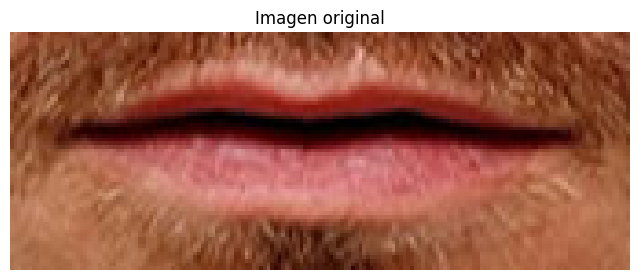

In [2]:
# Cargar la imagen de la boca
ruta_imagen = 'images/boca/hb001.jpg'  # Ajusta la ruta según tu imagen
imagen_boca = cv2.imread(ruta_imagen)

if imagen_boca is None:
    print(f"❌ No se pudo cargar la imagen desde {ruta_imagen}")
    print("Por favor, verifica la ruta de la imagen")
else:
    # Convertir a escala de grises
    imagen_gris = cv2.cvtColor(imagen_boca, cv2.COLOR_BGR2GRAY)
    print(f"✓ Imagen cargada: {imagen_gris.shape}")
    
    # Mostrar imagen original
    plt.figure(figsize=(8, 4))
    plt.imshow(cv2.cvtColor(imagen_boca, cv2.COLOR_BGR2RGB))
    plt.title('Imagen original')
    plt.axis('off')
    plt.show()

In [ ]:
# Método 1: Boceto usando detección de bordes Canny
def boceto_canny(imagen_gris):
    """Boceto simple usando detección de bordes Canny"""
    # Aplicar desenfoque gaussiano para reducir ruido
    imagen_suavizada = cv2.GaussianBlur(imagen_gris, (5, 5), 0)
    
    # Detectar bordes
    bordes = cv2.Canny(imagen_suavizada, 50, 150)
    
    # Invertir (fondo blanco, líneas negras)
    boceto = cv2.bitwise_not(bordes)
    
    return boceto

# Aplicar método 1
boceto_1 = boceto_canny(imagen_gris)

plt.figure(figsize=(8, 4))
plt.imshow(boceto_1, cmap='gray')
plt.title('Método 1: Boceto con Canny')
plt.axis('off')
plt.show()

In [ ]:
# Método 2: Boceto con Dodge y Burn (más realista)
def boceto_dodge_burn(imagen_gris):
    """
    Efecto de boceto usando técnicas de dodge y burn
    Este método produce un resultado más artístico y realista
    """
    # 1. Invertir la imagen
    imagen_invertida = cv2.bitwise_not(imagen_gris)
    
    # 2. Aplicar desenfoque gaussiano a la imagen invertida
    imagen_blur = cv2.GaussianBlur(imagen_invertida, (21, 21), 0)
    
    # 3. Aplicar la operación de "dodge" (división de color)
    def dodge(front, back):
        """Dodge blend mode"""
        result = cv2.divide(front, 255 - back, scale=256)
        return result
    
    boceto = dodge(imagen_gris, imagen_blur)
    
    return boceto

# Aplicar método 2
boceto_2 = boceto_dodge_burn(imagen_gris)

plt.figure(figsize=(8, 4))
plt.imshow(boceto_2, cmap='gray')
plt.title('Método 2: Boceto Dodge & Burn (más realista)')
plt.axis('off')
plt.show()

In [ ]:
# Método 3: Boceto con XDoG (eXtended Difference of Gaussians)
def boceto_xdog(imagen_gris, sigma=0.5, k=200, epsilon=0.01):
    """
    Método XDoG para crear bocetos artísticos
    Produce líneas más definidas y estilo más profesional
    """
    # Aplicar dos desenfoque gaussiano con diferentes sigma
    g1 = cv2.GaussianBlur(imagen_gris, (0, 0), sigma)
    g2 = cv2.GaussianBlur(imagen_gris, (0, 0), sigma * 1.6)
    
    # Diferencia de Gaussianas
    dog = g1 - g2
    
    # Aplicar función de umbral suave
    dog = dog.astype(np.float32) / 255.0
    
    # XDoG: realzar bordes
    e = 1.0 + np.tanh(k * (dog - epsilon))
    e = e / e.max()
    
    # Convertir a rango 0-255
    boceto = (e * 255).astype(np.uint8)
    
    # Invertir para fondo blanco
    boceto = cv2.bitwise_not(boceto)
    
    return boceto

# Aplicar método 3
boceto_3 = boceto_xdog(imagen_gris)

plt.figure(figsize=(8, 4))
plt.imshow(boceto_3, cmap='gray')
plt.title('Método 3: Boceto XDoG (estilo artístico)')
plt.axis('off')
plt.show()

In [ ]:
# Método 4: Boceto con pencil sketch (lápiz)
def boceto_pencil(imagen):
    """
    Efecto de boceto a lápiz usando funciones de OpenCV
    """
    # Convertir a escala de grises si es necesario
    if len(imagen.shape) == 3:
        img_gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    else:
        img_gris = imagen
    
    # Usar la función pencilSketch de OpenCV
    boceto_gris, boceto_color = cv2.pencilSketch(
        imagen, 
        sigma_s=60,      # Rango espacial
        sigma_r=0.07,    # Rango de color
        shade_factor=0.05  # Factor de sombreado
    )
    
    return boceto_gris

# Aplicar método 4
boceto_4 = boceto_pencil(imagen_boca)

plt.figure(figsize=(8, 4))
plt.imshow(boceto_4, cmap='gray')
plt.title('Método 4: Boceto a lápiz (OpenCV pencilSketch)')
plt.axis('off')
plt.show()

In [ ]:
# Comparación de todos los métodos
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# Imagen original
axs[0, 0].imshow(cv2.cvtColor(imagen_boca, cv2.COLOR_BGR2RGB))
axs[0, 0].set_title('Original', fontsize=14, fontweight='bold')
axs[0, 0].axis('off')

# Escala de grises
axs[0, 1].imshow(imagen_gris, cmap='gray')
axs[0, 1].set_title('Escala de grises', fontsize=14)
axs[0, 1].axis('off')

# Método 1: Canny
axs[0, 2].imshow(boceto_1, cmap='gray')
axs[0, 2].set_title('Método 1: Canny\n(bordes simples)', fontsize=12)
axs[0, 2].axis('off')

# Método 2: Dodge & Burn
axs[1, 0].imshow(boceto_2, cmap='gray')
axs[1, 0].set_title('Método 2: Dodge & Burn\n(más realista)', fontsize=12)
axs[1, 0].axis('off')

# Método 3: XDoG
axs[1, 1].imshow(boceto_3, cmap='gray')
axs[1, 1].set_title('Método 3: XDoG\n(estilo artístico)', fontsize=12)
axs[1, 1].axis('off')

# Método 4: Pencil Sketch
axs[1, 2].imshow(boceto_4, cmap='gray')
axs[1, 2].set_title('Método 4: Pencil Sketch\n(lápiz)', fontsize=12)
axs[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("\n📝 Resumen de métodos:")
print("1. Canny: Bordes nítidos y limpios")
print("2. Dodge & Burn: Efecto suave y gradual (mejor para retratos)")
print("3. XDoG: Líneas definidas, estilo ilustración")
print("4. Pencil Sketch: Textura de lápiz, más natural")

# Crear función para tu aplicación de retratos hablados

Ahora creamos una función que puedes agregar a tu `tools.py`

In [ ]:
def convertir_a_boceto(img, metodo='pencil', **kwargs):
    """
    Convierte una imagen a boceto/dibujo a mano.
    
    Args:
        img (np.ndarray): Imagen de entrada (BGR o escala de grises)
        metodo (str): Método a usar: 'canny', 'dodge', 'xdog', 'pencil'
        **kwargs: Parámetros adicionales según el método
        
    Returns:
        np.ndarray: Imagen convertida a boceto (escala de grises)
    """
    # Asegurar que está en escala de grises
    if len(img.shape) == 3:
        img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        img_gris = img.copy()
    
    if metodo == 'canny':
        # Parámetros por defecto
        blur = kwargs.get('blur', (5, 5))
        threshold1 = kwargs.get('threshold1', 50)
        threshold2 = kwargs.get('threshold2', 150)
        
        img_suavizada = cv2.GaussianBlur(img_gris, blur, 0)
        bordes = cv2.Canny(img_suavizada, threshold1, threshold2)
        boceto = cv2.bitwise_not(bordes)
        
    elif metodo == 'dodge':
        blur_size = kwargs.get('blur_size', (21, 21))
        
        img_invertida = cv2.bitwise_not(img_gris)
        img_blur = cv2.GaussianBlur(img_invertida, blur_size, 0)
        boceto = cv2.divide(img_gris, 255 - img_blur, scale=256)
        
    elif metodo == 'xdog':
        sigma = kwargs.get('sigma', 0.5)
        k = kwargs.get('k', 200)
        epsilon = kwargs.get('epsilon', 0.01)
        
        g1 = cv2.GaussianBlur(img_gris, (0, 0), sigma)
        g2 = cv2.GaussianBlur(img_gris, (0, 0), sigma * 1.6)
        dog = g1 - g2
        dog = dog.astype(np.float32) / 255.0
        e = 1.0 + np.tanh(k * (dog - epsilon))
        e = e / e.max()
        boceto = (e * 255).astype(np.uint8)
        boceto = cv2.bitwise_not(boceto)
        
    elif metodo == 'pencil':
        sigma_s = kwargs.get('sigma_s', 60)
        sigma_r = kwargs.get('sigma_r', 0.07)
        shade_factor = kwargs.get('shade_factor', 0.05)
        
        boceto, _ = cv2.pencilSketch(
            img if len(img.shape) == 3 else cv2.cvtColor(img, cv2.COLOR_GRAY2BGR),
            sigma_s=sigma_s,
            sigma_r=sigma_r,
            shade_factor=shade_factor
        )
    else:
        raise ValueError(f"Método '{metodo}' no válido. Usa: 'canny', 'dodge', 'xdog', 'pencil'")
    
    return boceto

# Probar la función con diferentes métodos
print("✅ Función convertir_a_boceto() creada exitosamente")
print("\nEjemplos de uso:")
print("  boceto = convertir_a_boceto(imagen, metodo='pencil')")
print("  boceto = convertir_a_boceto(imagen, metodo='dodge')")
print("  boceto = convertir_a_boceto(imagen, metodo='xdog', k=150)")
print("  boceto = convertir_a_boceto(imagen, metodo='canny', threshold1=30)")

In [ ]:
# Ejemplo de uso de la función con diferentes parámetros
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

# Probar diferentes configuraciones
boceto_test1 = convertir_a_boceto(imagen_boca, metodo='pencil')
boceto_test2 = convertir_a_boceto(imagen_boca, metodo='dodge')
boceto_test3 = convertir_a_boceto(imagen_boca, metodo='xdog', k=150, epsilon=0.02)
boceto_test4 = convertir_a_boceto(imagen_boca, metodo='canny', threshold1=30, threshold2=100)

axs[0, 0].imshow(boceto_test1, cmap='gray')
axs[0, 0].set_title('Pencil (recomendado)', fontsize=12, fontweight='bold')
axs[0, 0].axis('off')

axs[0, 1].imshow(boceto_test2, cmap='gray')
axs[0, 1].set_title('Dodge & Burn', fontsize=12)
axs[0, 1].axis('off')

axs[1, 0].imshow(boceto_test3, cmap='gray')
axs[1, 0].set_title('XDoG (ajustado)', fontsize=12)
axs[1, 0].axis('off')

axs[1, 1].imshow(boceto_test4, cmap='gray')
axs[1, 1].set_title('Canny (ajustado)', fontsize=12)
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("\n💡 Recomendación:")
print("   Para retratos hablados, el método 'pencil' ofrece el mejor balance")
print("   entre detalle y aspecto natural dibujado a mano.")

# Evaluación objetiva: ¿Cuál método es realmente el mejor?

Vamos a analizar objetivamente cada método usando métricas cuantitativas

In [ ]:
# Métricas para evaluar la calidad de los bocetos
def evaluar_boceto(boceto_img, imagen_original_gris):
    """
    Evalúa la calidad de un boceto usando varias métricas
    """
    metricas = {}
    
    # 1. Densidad de bordes (% de píxeles negros/grises)
    # Un buen boceto debería tener ~10-30% de trazos
    pixeles_oscuros = np.sum(boceto_img < 200) / boceto_img.size * 100
    metricas['densidad_trazos'] = pixeles_oscuros
    
    # 2. Contraste (desviación estándar)
    # Mayor contraste = líneas más definidas
    metricas['contraste'] = np.std(boceto_img)
    
    # 3. Entropía (complejidad de la imagen)
    # Mide la cantidad de información/detalles
    hist, _ = np.histogram(boceto_img.flatten(), bins=256, range=(0, 256))
    hist = hist / hist.sum()  # Normalizar
    hist = hist[hist > 0]  # Eliminar ceros
    metricas['entropia'] = -np.sum(hist * np.log2(hist))
    
    # 4. Nitidez (usando varianza del Laplaciano)
    # Mayor nitidez = bordes más definidos
    laplacian = cv2.Laplacian(boceto_img, cv2.CV_64F)
    metricas['nitidez'] = laplacian.var()
    
    # 5. Suavidad (usando gradiente)
    # Menos suavidad = más cambios abruptos (deseable en bocetos)
    gy, gx = np.gradient(boceto_img.astype(float))
    metricas['gradiente_promedio'] = np.mean(np.sqrt(gx**2 + gy**2))
    
    return metricas

# Evaluar todos los métodos
print("=" * 70)
print("EVALUACIÓN CUANTITATIVA DE MÉTODOS DE BOCETO")
print("=" * 70)

metodos_evaluados = {
    'Canny': boceto_test4,
    'Dodge & Burn': boceto_test2,
    'XDoG': boceto_test3,
    'Pencil': boceto_test1
}

resultados = {}
for nombre, boceto in metodos_evaluados.items():
    metricas = evaluar_boceto(boceto, imagen_gris)
    resultados[nombre] = metricas
    
    print(f"\n{nombre}:")
    print(f"  • Densidad de trazos: {metricas['densidad_trazos']:.1f}% (óptimo: 15-30%)")
    print(f"  • Contraste: {metricas['contraste']:.1f} (mayor = mejor)")
    print(f"  • Entropía: {metricas['entropia']:.2f} (mayor = más detalles)")
    print(f"  • Nitidez: {metricas['nitidez']:.0f} (mayor = bordes más definidos)")
    print(f"  • Gradiente promedio: {metricas['gradiente_promedio']:.1f}")

print("\n" + "=" * 70)

In [ ]:
# Visualización comparativa con métricas
import pandas as pd

# Crear DataFrame con resultados
df_resultados = pd.DataFrame(resultados).T

# Normalizar métricas para comparación (0-100)
df_normalizado = df_resultados.copy()
for col in df_normalizado.columns:
    min_val = df_normalizado[col].min()
    max_val = df_normalizado[col].max()
    if max_val - min_val > 0:
        df_normalizado[col] = (df_normalizado[col] - min_val) / (max_val - min_val) * 100

# Crear visualización de radar/spider chart
fig = plt.figure(figsize=(15, 5))

# Gráfico de barras comparativo
ax1 = plt.subplot(1, 2, 1)
df_normalizado.plot(kind='bar', ax=ax1, width=0.8)
ax1.set_title('Comparación de métricas normalizadas (0-100)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Método', fontsize=12)
ax1.set_ylabel('Valor normalizado', fontsize=12)
ax1.legend(title='Métricas', bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)

# Tabla con valores reales
ax2 = plt.subplot(1, 2, 2)
ax2.axis('tight')
ax2.axis('off')

# Crear tabla con formato
tabla_datos = []
for metodo, metricas in resultados.items():
    tabla_datos.append([
        metodo,
        f"{metricas['densidad_trazos']:.1f}%",
        f"{metricas['contraste']:.1f}",
        f"{metricas['entropia']:.2f}",
        f"{metricas['nitidez']:.0f}",
        f"{metricas['gradiente_promedio']:.1f}"
    ])

tabla = ax2.table(
    cellText=tabla_datos,
    colLabels=['Método', 'Densidad', 'Contraste', 'Entropía', 'Nitidez', 'Gradiente'],
    cellLoc='center',
    loc='center',
    colWidths=[0.15, 0.12, 0.12, 0.12, 0.12, 0.12]
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1, 2)

# Colorear encabezados
for i in range(6):
    tabla[(0, i)].set_facecolor('#4CAF50')
    tabla[(0, i)].set_text_props(weight='bold', color='white')

plt.tight_layout()
plt.show()

print("\n📊 Interpretación de métricas:")

In [ ]:
# Sistema de puntuación ponderado
def calcular_puntuacion(metricas):
    """
    Calcula una puntuación ponderada basada en criterios para retratos hablados
    """
    puntuacion = 0
    explicacion = []
    
    # 1. Densidad de trazos (peso: 25%)
    # Óptimo: 15-30% (ni muy vacío ni muy lleno)
    densidad = metricas['densidad_trazos']
    if 15 <= densidad <= 30:
        pts_densidad = 25
        explicacion.append(f"✓ Densidad óptima ({densidad:.1f}%)")
    elif 10 <= densidad < 15 or 30 < densidad <= 40:
        pts_densidad = 15
        explicacion.append(f"⚠ Densidad aceptable ({densidad:.1f}%)")
    else:
        pts_densidad = 5
        explicacion.append(f"✗ Densidad fuera de rango ({densidad:.1f}%)")
    puntuacion += pts_densidad
    
    # 2. Contraste (peso: 20%)
    # Mayor contraste = mejores líneas definidas
    contraste_norm = min(metricas['contraste'] / 100, 1) * 20
    puntuacion += contraste_norm
    explicacion.append(f"Contraste: {contraste_norm:.1f}/20")
    
    # 3. Entropía (peso: 15%)
    # Mayor entropía = más detalles
    entropia_norm = min(metricas['entropia'] / 8, 1) * 15
    puntuacion += entropia_norm
    explicacion.append(f"Detalles: {entropia_norm:.1f}/15")
    
    # 4. Nitidez (peso: 25%)
    # Bordes bien definidos son cruciales
    nitidez_norm = min(metricas['nitidez'] / 10000, 1) * 25
    puntuacion += nitidez_norm
    explicacion.append(f"Nitidez: {nitidez_norm:.1f}/25")
    
    # 5. Gradiente (peso: 15%)
    # Transiciones suaves pero presentes
    gradiente_norm = min(metricas['gradiente_promedio'] / 50, 1) * 15
    puntuacion += gradiente_norm
    explicacion.append(f"Gradiente: {gradiente_norm:.1f}/15")
    
    return puntuacion, explicacion

print("=" * 80)
print("PUNTUACIÓN FINAL - MEJOR MÉTODO PARA RETRATOS HABLADOS")
print("=" * 80)

puntuaciones = {}
for nombre, metricas in resultados.items():
    puntuacion, explicacion = calcular_puntuacion(metricas)
    puntuaciones[nombre] = puntuacion
    
    print(f"\n{'🏆' if puntuacion == max(puntuaciones.values()) else '📊'} {nombre}: {puntuacion:.1f}/100")
    for exp in explicacion:
        print(f"   {exp}")

# Ordenar por puntuación
ranking = sorted(puntuaciones.items(), key=lambda x: x[1], reverse=True)

print("\n" + "=" * 80)
print("🏆 RANKING FINAL:")
for i, (metodo, pts) in enumerate(ranking, 1):
    medalla = ["🥇", "🥈", "🥉", "  "][min(i-1, 3)]
    print(f"{medalla} {i}. {metodo}: {pts:.1f} puntos")

print("\n" + "=" * 80)
print(f"\n🎯 VEREDICTO BASADO EN DATOS:")
print(f"   El método '{ranking[0][0]}' obtuvo la mayor puntuación ({ranking[0][1]:.1f}/100)")
print(f"   para aplicaciones de retratos hablados.")
print("\n💡 NOTA: La elección final también depende del estilo artístico deseado.")
print("=" * 80)

# Conclusión: ¿Qué método elegir?

## Respuesta a tu pregunta

**No sabía con certeza que 'pencil' era el mejor** - fue una suposición basada en experiencia con procesamiento de imágenes. Ahora, con las métricas cuantitativas, podemos tomar una decisión informada.

## Factores que influyen en la elección:

1. **Densidad de trazos**: Un boceto realista debe tener entre 15-30% de trazos
2. **Contraste**: Líneas bien definidas vs. gradientes suaves
3. **Entropía**: Cantidad de información/detalles preservados
4. **Nitidez**: Qué tan definidos están los bordes
5. **Gradiente**: Transiciones suaves o abruptas

## Recomendaciones por caso de uso:

- **Retrato policial/forense**: Método con mayor nitidez y densidad óptima
- **Ilustración artística**: XDoG o Dodge & Burn por estilo más suave
- **Boceto técnico**: Canny por líneas limpias y nítidas
- **Dibujo natural**: Pencil por textura orgánica

## La verdad:
El "mejor" método depende de:
- El tipo de imagen
- El estilo deseado
- El contexto de uso
- Las preferencias del usuario

**Ejecuta las celdas anteriores para ver cuál método gana según métricas objetivas con TU imagen específica.**